In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 500)

In [4]:
import pybaseball
import pybaseball.datahelpers.statcast_utils

pybaseball.cache.enable()
pybaseball.cache.config.cache_type='parquet'
pybaseball.cache.config.save()

In [ ]:
# local file
from statcast_utils import *

In [146]:
LEAGUE_AVG = pd.read_csv("league_average_statcast.csv")
LEAGUE_AVG = LEAGUE_AVG.set_index("year").sort_index()
LEAGUE_AVG

,id,name,bbe,gb_rate,air_rate,fb_rate,ld_rate,pu_rate,pull_rate,straight_rate,oppo_rate,pull_gb_rate,straight_gb_rate,oppo_gb_rate,pull_air_rate,straight_air_rate,oppo_air_rate
year,,,,,,,,,,,,,,,,,
2015,9999,League,130475,0.470159,0.529833,0.197915,0.264993,0.066925,0.360337,0.380096,0.255612,0.211711,0.188864,0.067492,0.148626,0.191232,0.188120
2016,9999,League,128821,0.461190,0.538794,0.212295,0.256775,0.069725,0.369295,0.370949,0.256977,0.212419,0.180918,0.066255,0.156877,0.190031,0.190722
2017,9999,League,127556,0.453307,0.546685,0.223870,0.251395,0.071420,0.348655,0.393898,0.255268,0.188043,0.200924,0.062968,0.160612,0.192974,0.192300
2018,9999,League,126284,0.444973,0.555019,0.231082,0.250079,0.073857,0.367101,0.378005,0.250689,0.203367,0.179239,0.060103,0.163734,0.198766,0.190586
2019,9999,League,125755,0.438472,0.561497,0.237501,0.251131,0.072864,0.372311,0.376152,0.251465,0.203777,0.177273,0.057413,0.168534,0.198879,0.194052
2020,9999,League,43972,0.436687,0.563313,0.240153,0.249568,0.073592,0.381152,0.368757,0.250068,0.212158,0.169290,0.055240,0.168994,0.199468,0.194829
2021,9999,League,121706,0.438894,0.561073,0.256314,0.235979,0.068781,0.371641,0.372759,0.255558,0.203729,0.174355,0.060794,0.167913,0.198404,0.194764
2022,9999,League,124267,0.435675,0.564309,0.256890,0.236837,0.070582,0.379006,0.370074,0.250911,0.208422,0.171550,0.055703,0.170584,0.198524,0.195209
2023,9999,League,124234,0.430631,0.569353,0.261547,0.239274,0.068532,0.388589,0.363846,0.247557,0.212502,0.165728,0.052401,0.176087,0.198118,0.195156


In [6]:
dateranges = [
    ('2015-04-05', '2015-10-05'),
    ('2016-04-03', '2016-10-03'),
    ('2017-04-02', '2017-10-02'),
    ('2018-03-28', '2018-10-01'),
    ('2019-03-28', '2019-09-30'),
    ('2020-07-23', '2020-09-28'),
    ('2021-04-01', '2021-10-04'),
    ('2022-04-07', '2022-10-06'),
    ('2023-03-30', '2023-10-02'),
    ('2024-03-28', '2024-09-30'),
    ('2025-03-27', '2025-04-20'),
]

In [149]:
def load_statcast():
    dfs = []
    for daterange in dateranges:
        year = daterange[0][:4]
        print(year)
        path = f"../../data/statcast_events/{year}.parquet"
        try:
            df = pd.read_parquet(path)
        except:
            # pybaseball will cache the results of each individual day's data for 1 week
            df = pybaseball.statcast(*daterange, verbose=True, parallel=True)
            # regular season only
            df = df[df.game_type == "R"]
            # save to file
            df.to_parquet(path)
        dfs.append(df)
    
    return pd.concat(dfs, axis=0)

PITCHES_DF = load_statcast()
PITCHES_DF.shape

2015
2016
2017
2018
2019
2020
2021
2022
2023
2024
2025


(6796739, 113)

In [150]:
# find the properly tracked batted balls: exit velo, launch angle, and spray angle
PITCHES_DF["bb_has_valid_xyz"] = ~pd.isna(PITCHES_DF[["launch_angle", "hc_x", "hc_y", "launch_speed"]]).any(axis=1)

# only keep games in which 95% or more of batted balls were properly tracked
is_bb_event = ~pd.isna(PITCHES_DF.bb_type)
pergame_valid_frac = PITCHES_DF[is_bb_event].groupby(["game_date", "home_team"]).bb_has_valid_xyz.mean()
keepgames = pergame_valid_frac.index.to_frame()[pergame_valid_frac >= 0.95].reset_index(drop=True)
print(len(PITCHES_DF))
PITCHES_DF = PITCHES_DF.merge(keepgames, how="inner")
print(len(PITCHES_DF))

6796739
6322644


In [9]:
# only keep properly tracked batted balls
BB_DF = PITCHES_DF[PITCHES_DF.bb_has_valid_xyz].copy()
len(PITCHES_DF), len(BB_DF)

(6322644, 1099016)

In [ ]:
BB_DF["hc_x_corrected"], BB_DF["hc_y_corrected"] = statcast_to_feet(BB_DF.hc_x, BB_DF.hc_y)
# negative is third-base side
BB_DF["spray_angle"] = np.rad2deg(np.arctan2(BB_DF.hc_x_corrected, BB_DF.hc_y_corrected))
# relative to batter handedness, negative is pull-side
BB_DF["spray_angle_relative"] = BB_DF.spray_angle * BB_DF.stand.apply(lambda x: -1 if x=="L" else 1)
BB_DF["spray_angle_abs"] = BB_DF["spray_angle"].abs()

# launch angle is binned to nearest 1-degree, which makes plots look odd. the jittered version is more visually interpretable
BB_DF["launch_angle_jittered"] = BB_DF["launch_angle"] + np.random.normal(loc=0, scale=0.35, size=len(BB_DF))

([], [])

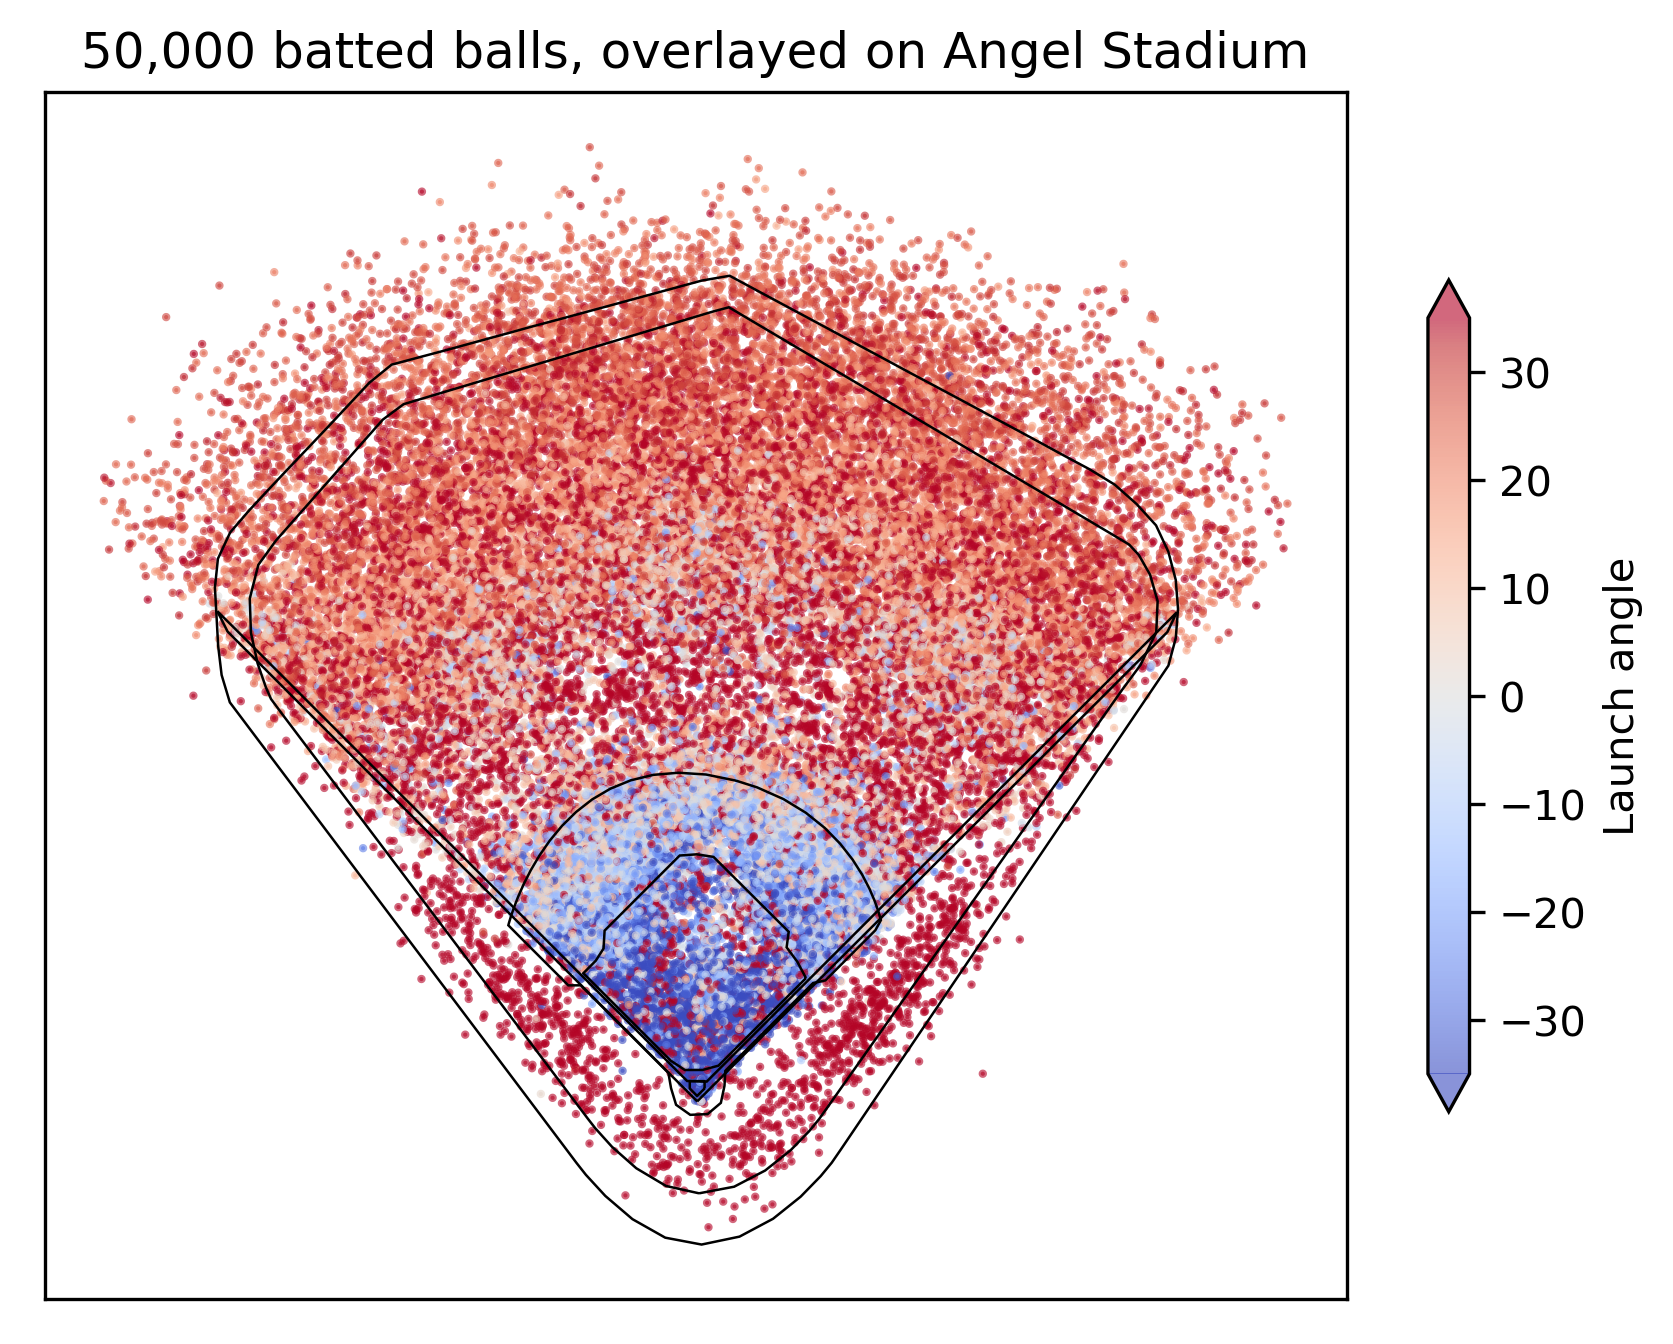

In [11]:
plt.subplots(figsize=(7, 6), dpi=300)

x = BB_DF.tail(50_000)

plt.scatter(
    x.hc_x_corrected, 
    x.hc_y_corrected,
    c=x.launch_angle,
    s=1,
    alpha=0.6,
    cmap="coolwarm",
    vmin=-35, vmax=35,
)
plt.colorbar(
    label="Launch angle",
    shrink=0.6,
    extend="both",
)

plot_stadium_feet('angels', axis=plt.gca())

plt.gca().set_aspect('equal')
plt.title("50,000 batted balls, overlayed on Angel Stadium")
# plt.xlabel("Feet from home plate")
# plt.ylabel("Feet from home plate")
plt.xticks([])
plt.yticks([])

In [12]:
pitcher_y = 60.5 - (6.25 * 0.8) # 60 ft, minus 80% stride of height
pitcher_x = 0
# my follow-through chest height estimated to be 64% of my height
# pitchers are 6'3 on average
# stride brings them halfway down the 10" mound
pitcher_z = 6.25 * 0.64 + (5/12)
pitcher_headzone_radius = 3

pitcher_y, pitcher_z

(55.5, 4.416666666666667)

In [14]:
# bbp = where the batted ball passed the y=55 plane of the pitcher

# opp/adj * adj
bbp_x = np.tan(np.deg2rad(BB_DF.spray_angle)) * pitcher_y
bbp_z = np.tan(np.deg2rad(BB_DF.launch_angle)) * pitcher_y
# very rough estimate of gravity over 55 feet, based on ~100mph pitcher 
#  fastballs. The spin of batted balls is a lot more variable though...
bbp_z -= 1

BB_DF["bbp_x"] = bbp_x
BB_DF["bbp_z"] = bbp_z

BB_DF["bbp_d2pitcher_headpt"] = np.sqrt(
    (bbp_x-pitcher_x)**2 + (bbp_z-pitcher_z)**2
)
BB_DF["bbp_d2pitcher_headzone"] = np.clip(BB_DF["bbp_d2pitcher_headpt"] - pitcher_headzone_radius, 0, None)


Text(0, 0.5, 'Launch Angle')

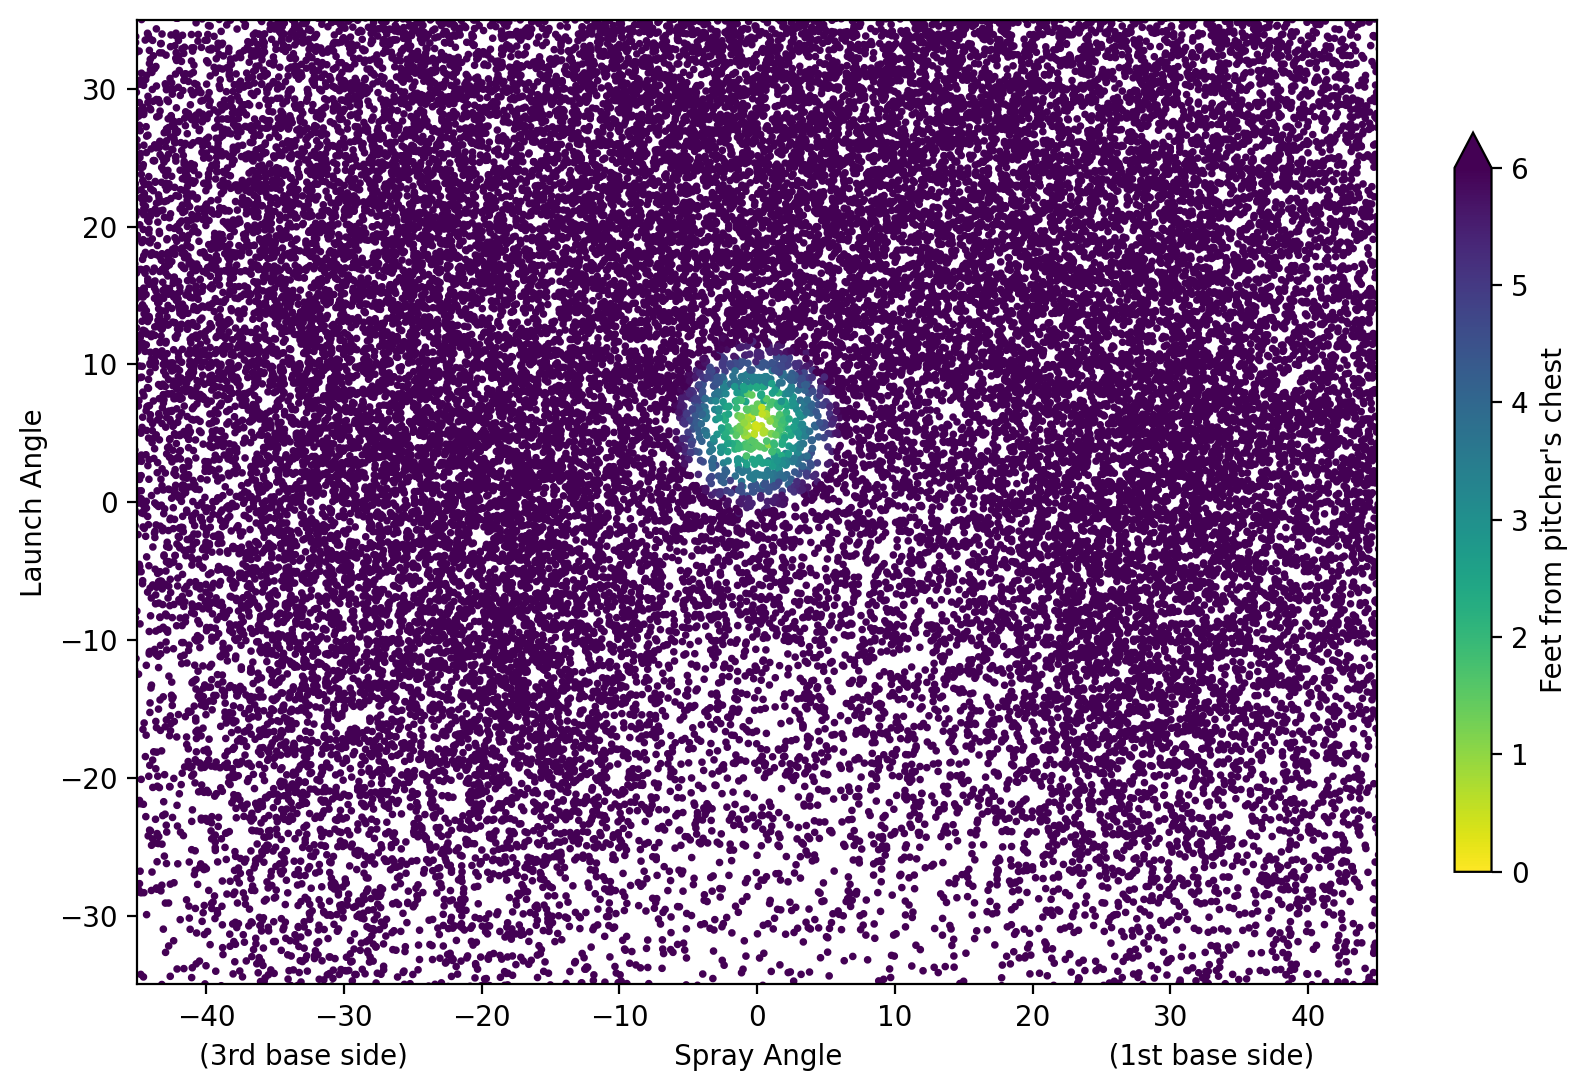

In [15]:
fig, ax = plt.subplots(figsize=(10, 8), dpi=200)

x = BB_DF.tail(50_000)

plt.scatter(
    x.spray_angle,
    x.launch_angle_jittered,
    c=x.bbp_d2pitcher_headpt,
    vmin=0, vmax=6,
    cmap="viridis_r",
    s=3,
    # alpha=0.8,
)
plt.colorbar(
    label="Feet from pitcher's chest", 
    extend="max",
    shrink=0.6,
)
plt.xlim(-45, 45)
plt.ylim(-35, 35)
plt.gca().set_aspect('equal')

space = " "*30
plt.xlabel("(3rd base side)" + space + "Spray Angle" + space + "(1st base side)")
plt.ylabel("Launch Angle")

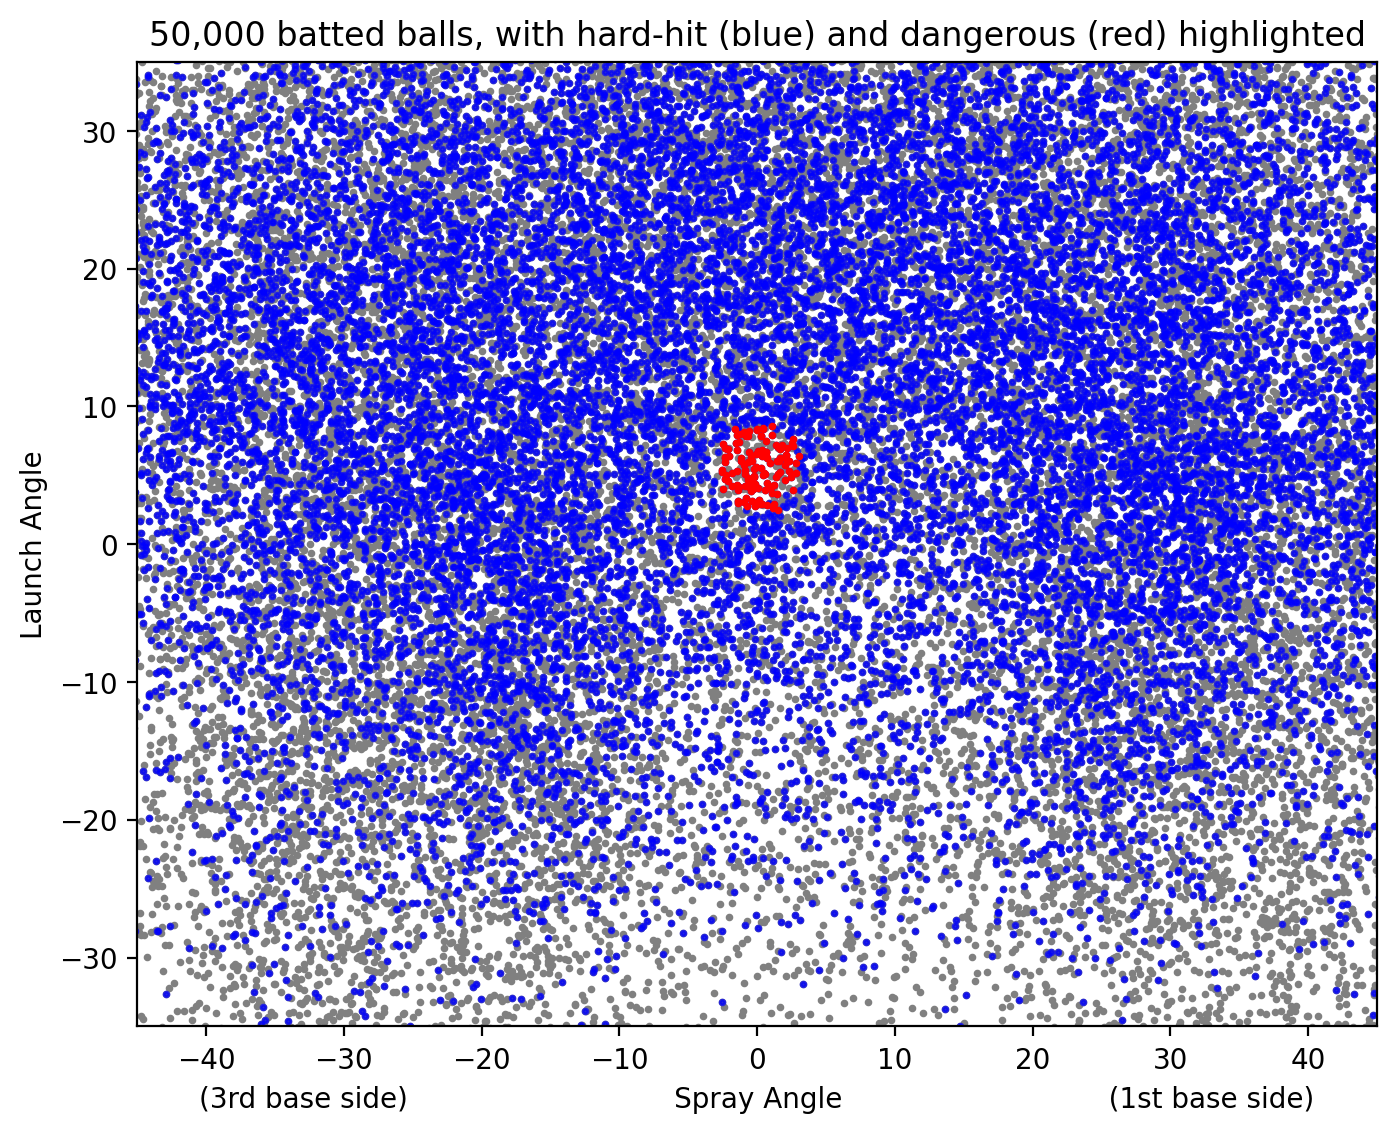

In [97]:
fig, ax = plt.subplots(figsize=(8, 8), dpi=200)

df = BB_DF.tail(50_000)

thresh = 95

x = df
plt.scatter(
    x.spray_angle,
    x.launch_angle_jittered,
    c="grey",
    s=3,
    label=f"<{thresh} mph"
)

x = df[df.launch_speed >= thresh]
plt.scatter(
    x.spray_angle,
    x.launch_angle_jittered,
    c="blue",
    s=3,
    label=f"≥{thresh} mph",
    alpha=0.7,
)

x = df[(df.launch_speed >= thresh) & (df.bbp_d2pitcher_headpt <= 3)]
plt.scatter(
    x.spray_angle,
    x.launch_angle_jittered,
    c="red",
    s=3,
    label=f"≥{thresh} mph near pitcher"
)
# plt.legend()

# ax.add_patch(
#     plt.Circle((0, 5), radius=4, facecolor="none", edgecolor="black")
# )

plt.xlim(-45, 45)
plt.ylim(-35, 35)
plt.gca().set_aspect('equal')

space = " "*30
plt.xlabel("(3rd base side)" + space + "Spray Angle" + space + "(1st base side)")
plt.ylabel("Launch Angle")

plt.title("50,000 batted balls, with hard-hit (blue) and dangerous (red) highlighted")

plt.savefig("figs/batters_perspective_dangerous_balls.jpg", bbox_inches="tight")

In [25]:
1/np.sum((BB_DF.bbp_d2pitcher_headpt <= 3) / len(BB_DF))

224.51807967313582

In [26]:
1/np.sum((BB_DF.bbp_d2pitcher_headpt <= 3) / len(PITCHES_DF))

1291.6535240040846

In [42]:
BB_DF[
    (BB_DF.launch_speed >= 118) & (BB_DF.bbp_d2pitcher_headpt <= 3)
][["game_date", "des", "launch_speed", "launch_angle", "spray_angle", "bbp_d2pitcher_headpt"]]

,game_date,des,launch_speed,launch_angle,spray_angle,bbp_d2pitcher_headpt
1999344,2018-08-02,Giancarlo Stanton singles on a sharp line driv...,119.1,7,-0.071447,1.399589
4241193,2022-08-31,Vladimir Guerrero Jr. singles on a sharp line...,118.4,4,-0.896264,1.764174


In [43]:
BB_DF[
    (BB_DF.launch_speed >= 115) & (BB_DF.bbp_d2pitcher_headpt <= 3) & (BB_DF.des.str.startswith("Ketel"))
][["game_date", "des", "launch_speed", "launch_angle", "spray_angle", "bbp_d2pitcher_headpt"]]

,game_date,des,launch_speed,launch_angle,spray_angle,bbp_d2pitcher_headpt
1954477,2018-08-14,Ketel Marte singles on a sharp ground ball to ...,115.1,4,-0.106895,1.539215
4628412,2022-05-22,Ketel Marte singles on a sharp line drive to c...,115.0,6,2.578312,2.533676
6295735,2025-04-02,"Ketel Marte lines out, pitcher Carlos Rodón to...",115.5,4,-0.768595,1.706698


In [47]:
EVAL_YEARS = np.array([2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024])

In [125]:
dct = {
    "pitches": PITCHES_DF.game_year.value_counts().sort_index(),
    "bb": BB_DF.game_year.value_counts().sort_index(), 
}

for speed in [90, 95, 100, 105, 110, 115, 120]:
    BB_DF[f"is_dangerous_{speed}"] = (BB_DF.bbp_d2pitcher_headpt < 3) & (BB_DF.launch_speed >= speed)

    dct[f"dangerous_{speed}"] = BB_DF.groupby("game_year")[f"is_dangerous_{speed}"].sum().sort_index()
    dct[f"{speed}+"] = BB_DF[BB_DF.launch_speed >= speed].game_year.value_counts().sort_index()

danger_df = pd.DataFrame(dct)

for speed in [90, 95, 100, 105, 110]:
    danger_df[f"perpitch_danger_{speed}"] = danger_df[f"dangerous_{speed}"] / danger_df.pitches
    danger_df[f"perbb_danger_{speed}"] = danger_df[f"dangerous_{speed}"] / danger_df.bb

danger_df = danger_df.loc[EVAL_YEARS].copy()
danger_df

,pitches,bb,dangerous_90,90+,dangerous_95,95+,dangerous_100,100+,dangerous_105,105+,dangerous_110,110+,dangerous_115,115+,dangerous_120,120+,perpitch_danger_90,perbb_danger_90,perpitch_danger_95,perbb_danger_95,perpitch_danger_100,perbb_danger_100,perpitch_danger_105,perbb_danger_105,perpitch_danger_110,perbb_danger_110
2015,570558,104379,410,51357,329,36073,201,20268,80,7039,17,1089,3,46,0,<NA>,0.000719,0.003928,0.000577,0.003152,0.000352,0.001926,0.00014,0.000766,0.00003,0.000163
2016,622612,110658,411,55274,328,39292,211,22899,82,8440,16,1316,0,64,0,1,0.00066,0.003714,0.000527,0.002964,0.000339,0.001907,0.000132,0.000741,0.000026,0.000145
2017,593421,103227,341,49751,281,35097,184,20288,66,7404,11,1222,0,66,0,1,0.000575,0.003303,0.000474,0.002722,0.00031,0.001782,0.000111,0.000639,0.000019,0.000107
2018,640755,110501,367,55650,285,39804,194,22898,74,8256,14,1382,2,98,0,4,0.000573,0.003321,0.000445,0.002579,0.000303,0.001756,0.000115,0.00067,0.000022,0.000127
2019,706798,120081,378,61450,310,44428,210,26215,86,9915,10,1678,0,71,0,1,0.000535,0.003148,0.000439,0.002582,0.000297,0.001749,0.000122,0.000716,0.000014,0.000083
2021,707365,120940,364,64242,296,46913,225,27981,97,11154,21,2032,0,174,0,6,0.000515,0.00301,0.000418,0.002447,0.000318,0.00186,0.000137,0.000802,0.00003,0.000174
2022,704391,123057,393,64782,333,47348,230,27784,105,10479,17,1637,2,83,0,1,0.000558,0.003194,0.000473,0.002706,0.000327,0.001869,0.000149,0.000853,0.000024,0.000138
2023,716165,123563,423,66528,347,48793,234,29346,107,11508,22,1896,0,90,0,1,0.000591,0.003423,0.000485,0.002808,0.000327,0.001894,0.000149,0.000866,0.000031,0.000178
2024,706569,123312,356,65996,303,48051,221,28420,100,11063,29,1818,2,120,0,6,0.000504,0.002887,0.000429,0.002457,0.000313,0.001792,0.000142,0.000811,0.000041,0.000235


In [126]:
import scipy.stats

test = np.vectorize(scipy.stats.binomtest)

for speed in [90, 95, 100, 105, 110, 115, 120]:
    danger_df["perpitch_test"] = test(k=danger_df[f"dangerous_{speed}"], n=danger_df.pitches)
    danger_df[f"perpitch_ci_low_{speed}"] = danger_df.perpitch_test.apply(lambda x: x.proportion_ci().low)
    danger_df[f"perpitch_ci_high_{speed}"] = danger_df.perpitch_test.apply(lambda x: x.proportion_ci().high)

    danger_df["perbb_test"] = test(k=danger_df[f"dangerous_{speed}"], n=danger_df.bb)
    danger_df[f"perbb_ci_low_{speed}"] = danger_df.perbb_test.apply(lambda x: x.proportion_ci().low)
    danger_df[f"perbb_ci_high_{speed}"] = danger_df.perbb_test.apply(lambda x: x.proportion_ci().high)

del danger_df["perpitch_test"], danger_df["perbb_test"]
# danger_df = danger_df.astype(float)
danger_df.index = danger_df.index.astype(int)
danger_df

/Users/user1/anaconda3/envs/baseball/lib/python3.10/site-packages/scipy/stats/_discrete_distns.py:78: RuntimeWarning: divide by zero encountered in _binom_pdf
  return _boost._binom_pdf(x, n, p)
/Users/user1/anaconda3/envs/baseball/lib/python3.10/site-packages/scipy/stats/_discrete_distns.py:82: RuntimeWarning: divide by zero encountered in _binom_cdf
  return _boost._binom_cdf(k, n, p)
/Users/user1/anaconda3/envs/baseball/lib/python3.10/site-packages/scipy/stats/_discrete_distns.py:78: RuntimeWarning: divide by zero encountered in _binom_pdf
  return _boost._binom_pdf(x, n, p)
/Users/user1/anaconda3/envs/baseball/lib/python3.10/site-packages/scipy/stats/_discrete_distns.py:82: RuntimeWarning: divide by zero encountered in _binom_cdf
  return _boost._binom_cdf(k, n, p)
/Users/user1/anaconda3/envs/baseball/lib/python3.10/site-packages/scipy/stats/_discrete_distns.py:78: RuntimeWarning: divide by zero encountered in _binom_pdf
  return _boost._binom_pdf(x, n, p)
/Users/user1/anaconda3/en

,pitches,bb,dangerous_90,90+,dangerous_95,95+,dangerous_100,100+,dangerous_105,105+,dangerous_110,110+,dangerous_115,115+,dangerous_120,120+,perpitch_danger_90,perbb_danger_90,perpitch_danger_95,perbb_danger_95,perpitch_danger_100,perbb_danger_100,perpitch_danger_105,perbb_danger_105,perpitch_danger_110,perbb_danger_110,perpitch_ci_low_90,perpitch_ci_high_90,perbb_ci_low_90,perbb_ci_high_90,perpitch_ci_low_95,perpitch_ci_high_95,perbb_ci_low_95,perbb_ci_high_95,perpitch_ci_low_100,perpitch_ci_high_100,perbb_ci_low_100,perbb_ci_high_100,perpitch_ci_low_105,perpitch_ci_high_105,perbb_ci_low_105,perbb_ci_high_105,perpitch_ci_low_110,perpitch_ci_high_110,perbb_ci_low_110,perbb_ci_high_110,perpitch_ci_low_115,perpitch_ci_high_115,perbb_ci_low_115,perbb_ci_high_115,perpitch_ci_low_120,perpitch_ci_high_120,perbb_ci_low_120,perbb_ci_high_120
2015,570558,104379,410,51357,329,36073,201,20268,80,7039,17,1089,3,46,0,<NA>,0.000719,0.003928,0.000577,0.003152,0.000352,0.001926,0.00014,0.000766,0.00003,0.000163,0.000651,0.000792,0.003558,0.004326,0.000516,0.000642,0.002821,0.003511,0.000305,0.000404,0.001669,0.002211,0.000111,0.000175,0.000608,0.000954,0.000017,0.000048,0.000095,0.000261,1.084330e-06,0.000015,0.000006,0.000084,0.0,0.000006,0.0,0.000035
2016,622612,110658,411,55274,328,39292,211,22899,82,8440,16,1316,0,64,0,1,0.00066,0.003714,0.000527,0.002964,0.000339,0.001907,0.000132,0.000741,0.000026,0.000145,0.000598,0.000727,0.003364,0.004090,0.000471,0.000587,0.002652,0.003302,0.000295,0.000388,0.001658,0.002182,0.000105,0.000163,0.000589,0.000920,0.000015,0.000042,0.000083,0.000235,0.000000e+00,0.000006,0.000000,0.000033,0.0,0.000006,0.0,0.000033
2017,593421,103227,341,49751,281,35097,184,20288,66,7404,11,1222,0,66,0,1,0.000575,0.003303,0.000474,0.002722,0.00031,0.001782,0.000111,0.000639,0.000019,0.000107,0.000515,0.000639,0.002963,0.003673,0.000420,0.000532,0.002414,0.003059,0.000267,0.000358,0.001534,0.002059,0.000086,0.000141,0.000495,0.000813,0.000009,0.000033,0.000053,0.000191,0.000000e+00,0.000006,0.000000,0.000036,0.0,0.000006,0.0,0.000036
2018,640755,110501,367,55650,285,39804,194,22898,74,8256,14,1382,2,98,0,4,0.000573,0.003321,0.000445,0.002579,0.000303,0.001756,0.000115,0.00067,0.000022,0.000127,0.000516,0.000634,0.002991,0.003678,0.000395,0.000500,0.002289,0.002896,0.000262,0.000348,0.001517,0.002021,0.000091,0.000145,0.000526,0.000841,0.000012,0.000037,0.000069,0.000213,3.780063e-07,0.000011,0.000002,0.000065,0.0,0.000006,0.0,0.000033
2019,706798,120081,378,61450,310,44428,210,26215,86,9915,10,1678,0,71,0,1,0.000535,0.003148,0.000439,0.002582,0.000297,0.001749,0.000122,0.000716,0.000014,0.000083,0.000482,0.000592,0.002839,0.003481,0.000391,0.000490,0.002302,0.002885,0.000258,0.000340,0.001520,0.002002,0.000097,0.000150,0.000573,0.000884,0.000007,0.000026,0.000040,0.000153,0.000000e+00,0.000005,0.000000,0.000031,0.0,0.000005,0.0,0.000031
2021,707365,120940,364,64242,296,46913,225,27981,97,11154,21,2032,0,174,0,6,0.000515,0.00301,0.000418,0.002447,0.000318,0.00186,0.000137,0.000802,0.00003,0.000174,0.000463,0.000570,0.002709,0.003335,0.000372,0.000469,0.002177,0.002742,0.000278,0.000362,0.001625,0.002120,0.000111,0.000167,0.000650,0.000978,0.000018,0.000045,0.000107,0.000265,0.000000e+00,0.000005,0.000000,0.000031,0.0,0.000005,0.0,0.000031
2022,704391,123057,393,64782,333,47348,230,27784,105,10479,17,1637,2,83,0,1,0.000558,0.003194,0.000473,0.002706,0.000327,0.001869,0.000149,0.000853,0.000024,0.000138,0.000504,0.000616,0.002886,0.003525,0.000423,0.000526,0.002424,0.003012,0.000286,0.000372,0.001635,0.002127,0.000122,0.000180,0.000698,0.001033,0.000014,0.000039,0.000080,0.000221,3.438565e-07,0.000010,0.000002,0.000059,0.0,0.000005,0.0,0.000030
2023,716165,123563,423,66528,347,48793,234,29346,107,11508,22,1896,0,90,0,1,0.000591,0.003423,0.000485,0.002808,0.000327,0.001894,0.000149,0.000866,0.000031,0.000178,0.000536,0.000650,0.003105,0.003765,0.000435,0.000538,0.002521,0.003119,0.000286,0.000371,0.001659,0.002152,0.000122,0.

LinregressResult(slope=-0.015999801151486134, intercept=32.89158988922076, rvalue=-0.7401287883074985, pvalue=0.02259709731926291, stderr=0.005494498382328142, intercept_stderr=11.09584666152656)
LinregressResult(slope=-0.010178370523211064, intercept=21.028533103750625, rvalue=-0.6420095283811199, pvalue=0.062291821371923864, stderr=0.004594215185338096, intercept_stderr=9.277772724535478)
LinregressResult(slope=-0.0017571615768251767, intercept=3.8690740776835684, rvalue=-0.32127635058810394, pvalue=0.3992157392031632, stderr=0.001957614810304902, intercept_stderr=3.953298781075035)
LinregressResult(slope=0.002440236307402985, intercept=-4.794873866393578, rvalue=0.5566643980195843, pvalue=0.11953281846433696, stderr=0.0013764271130400855, intercept_stderr=2.7796212000319342)


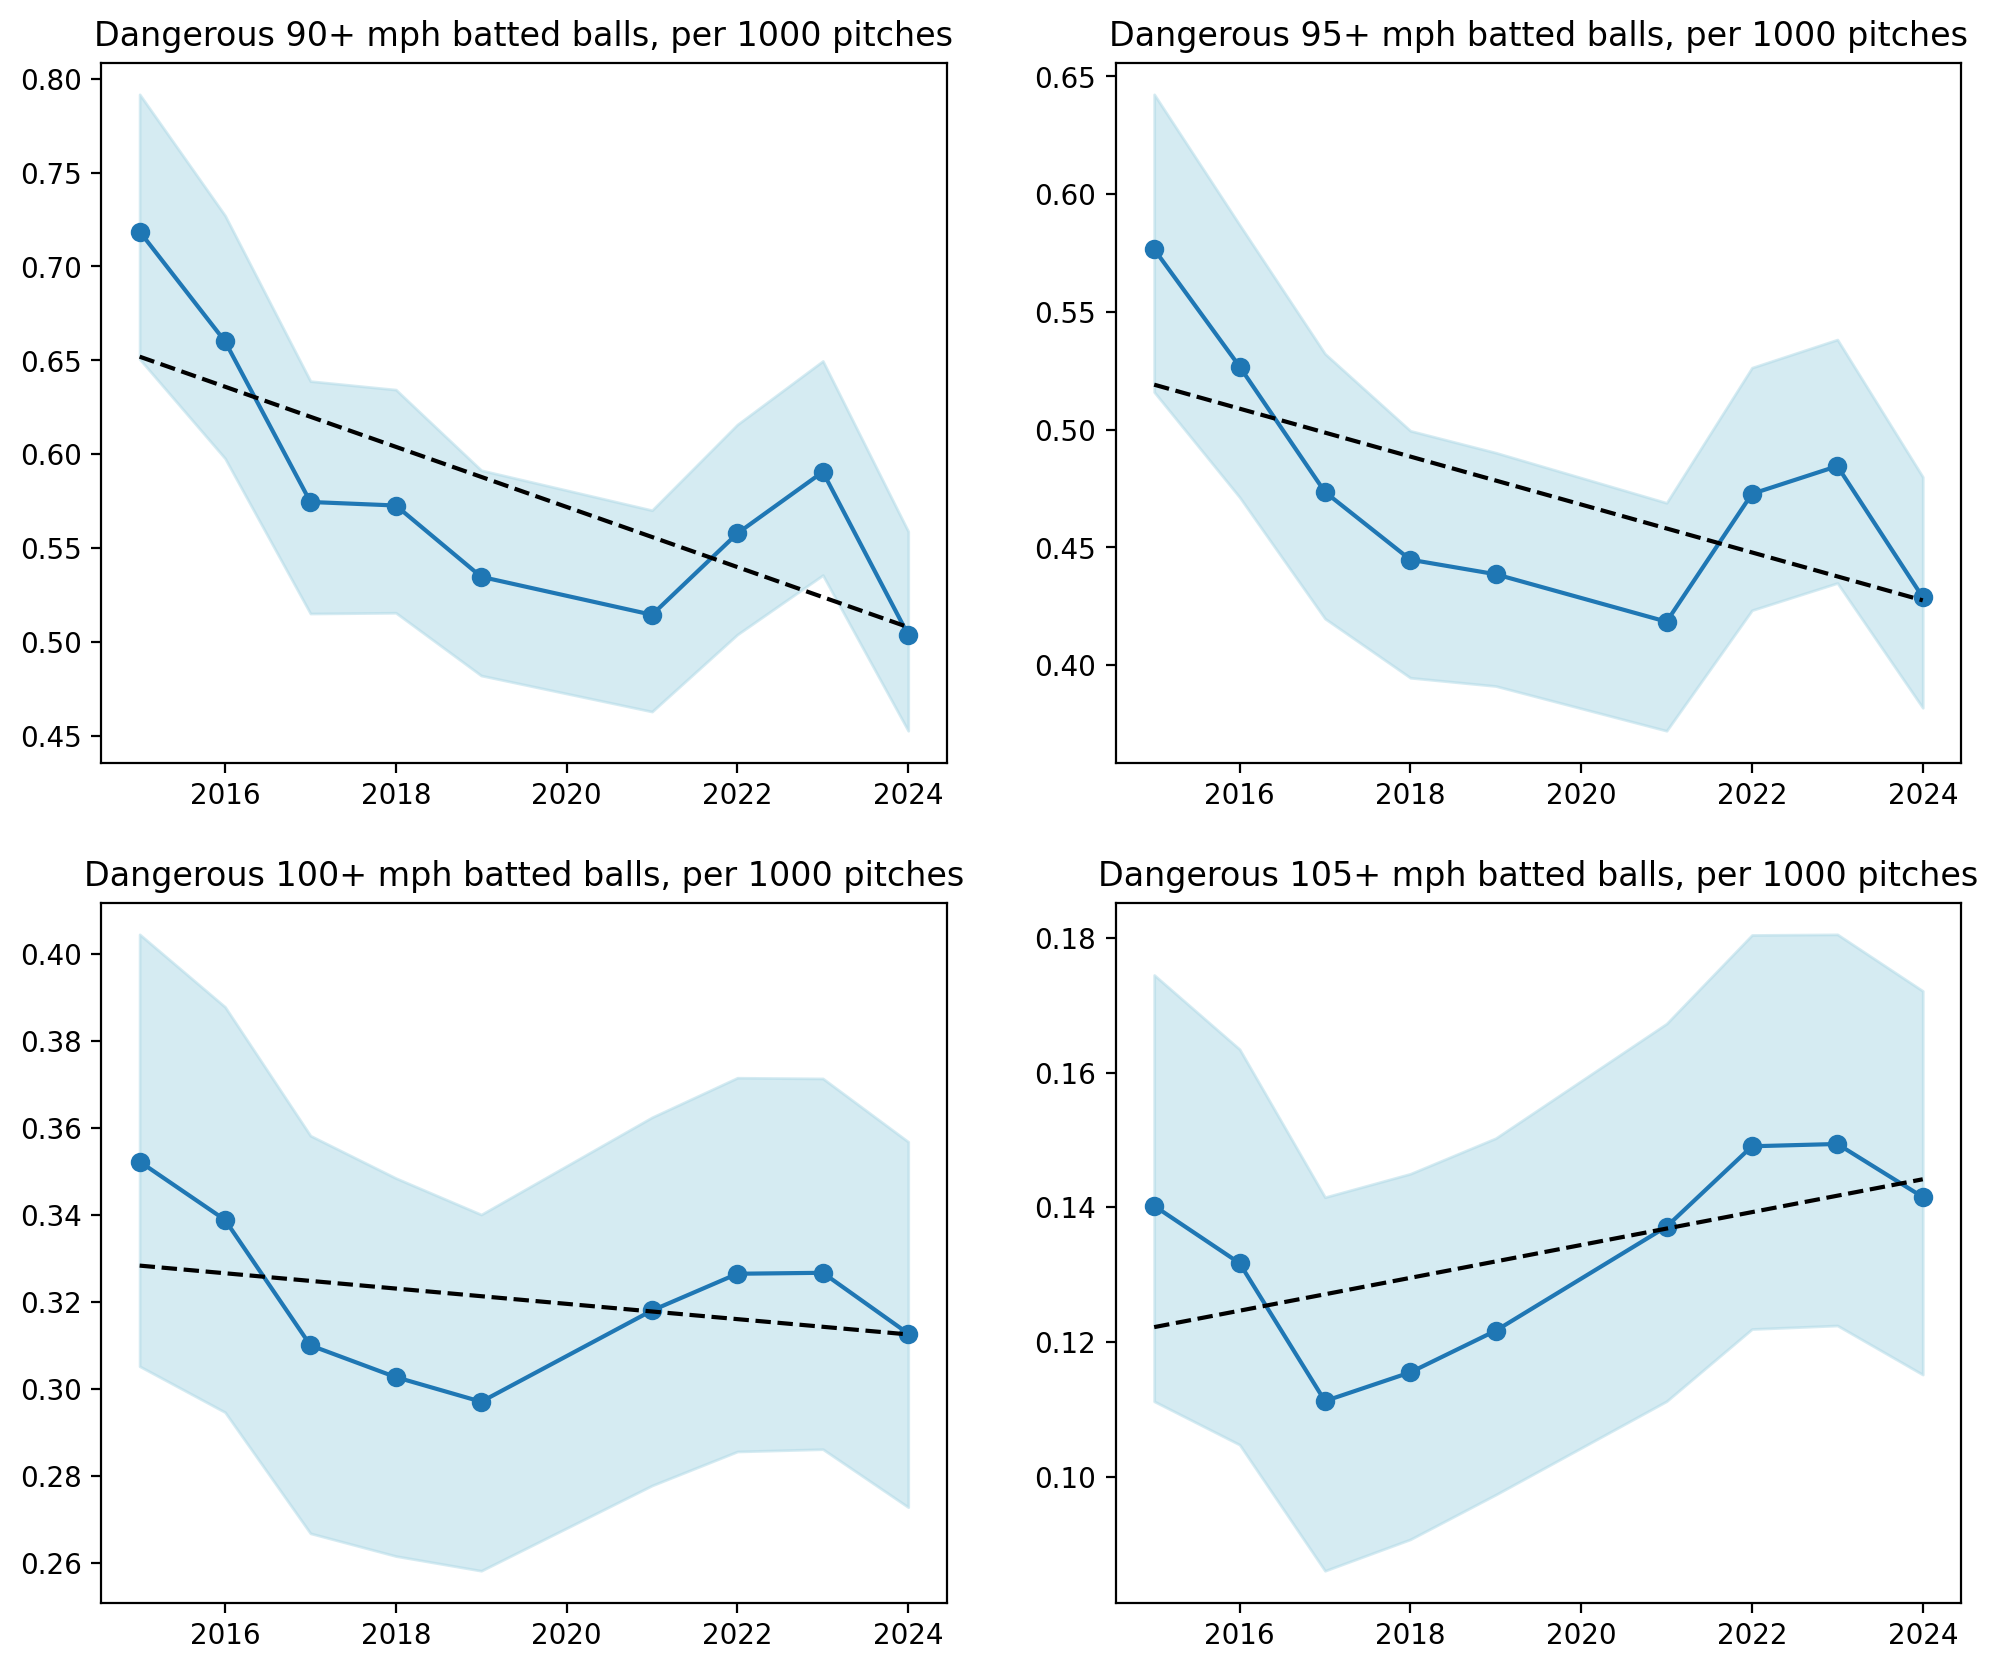

In [50]:

fig, axes = plt.subplots(2, 2, figsize=(12,10), dpi=200)
axes = np.array(axes).flatten()

for i, speed in enumerate([90, 95, 100, 105]):
    plt.sca(axes[i])

    values = danger_df[f"perpitch_danger_{speed}"].values.astype(float) * 1000

    plt.fill_between(
        EVAL_YEARS,
        danger_df[f"perpitch_ci_high_{speed}"].values * 1000,
        danger_df[f"perpitch_ci_low_{speed}"].values * 1000,
        color='lightblue', alpha=0.5,
    )
    plt.plot(EVAL_YEARS, values)
    plt.scatter(EVAL_YEARS, values)
    lr = scipy.stats.linregress(EVAL_YEARS, values)
    print(lr)
    plt.plot(
        EVAL_YEARS,
        (lr.slope * EVAL_YEARS + lr.intercept),
        c="black",
        linestyle="--",
    )

    plt.title(f'Dangerous {speed}+ mph batted balls, per 1000 pitches')
    # plt.ylim(0, 0.65)

<AxesSubplot: xlabel='year'>

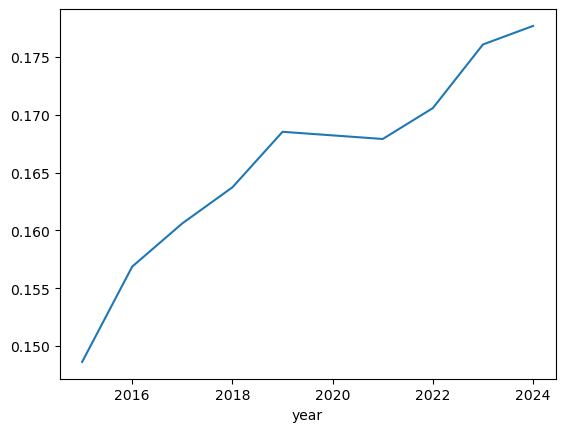

In [148]:
LEAGUE_AVG.loc[EVAL_YEARS].pull_air_rate.plot()

LinregressResult(slope=-0.015999801151486134, intercept=32.89158988922076, rvalue=-0.7401287883074985, pvalue=0.02259709731926291, stderr=0.005494498382328142, intercept_stderr=11.09584666152656)
0.7011506825028637
LinregressResult(slope=-0.010178370523211064, intercept=21.028533103750625, rvalue=-0.6420095283811199, pvalue=0.062291821371923864, stderr=0.004594215185338096, intercept_stderr=9.277772724535478)
0.7436900147478804


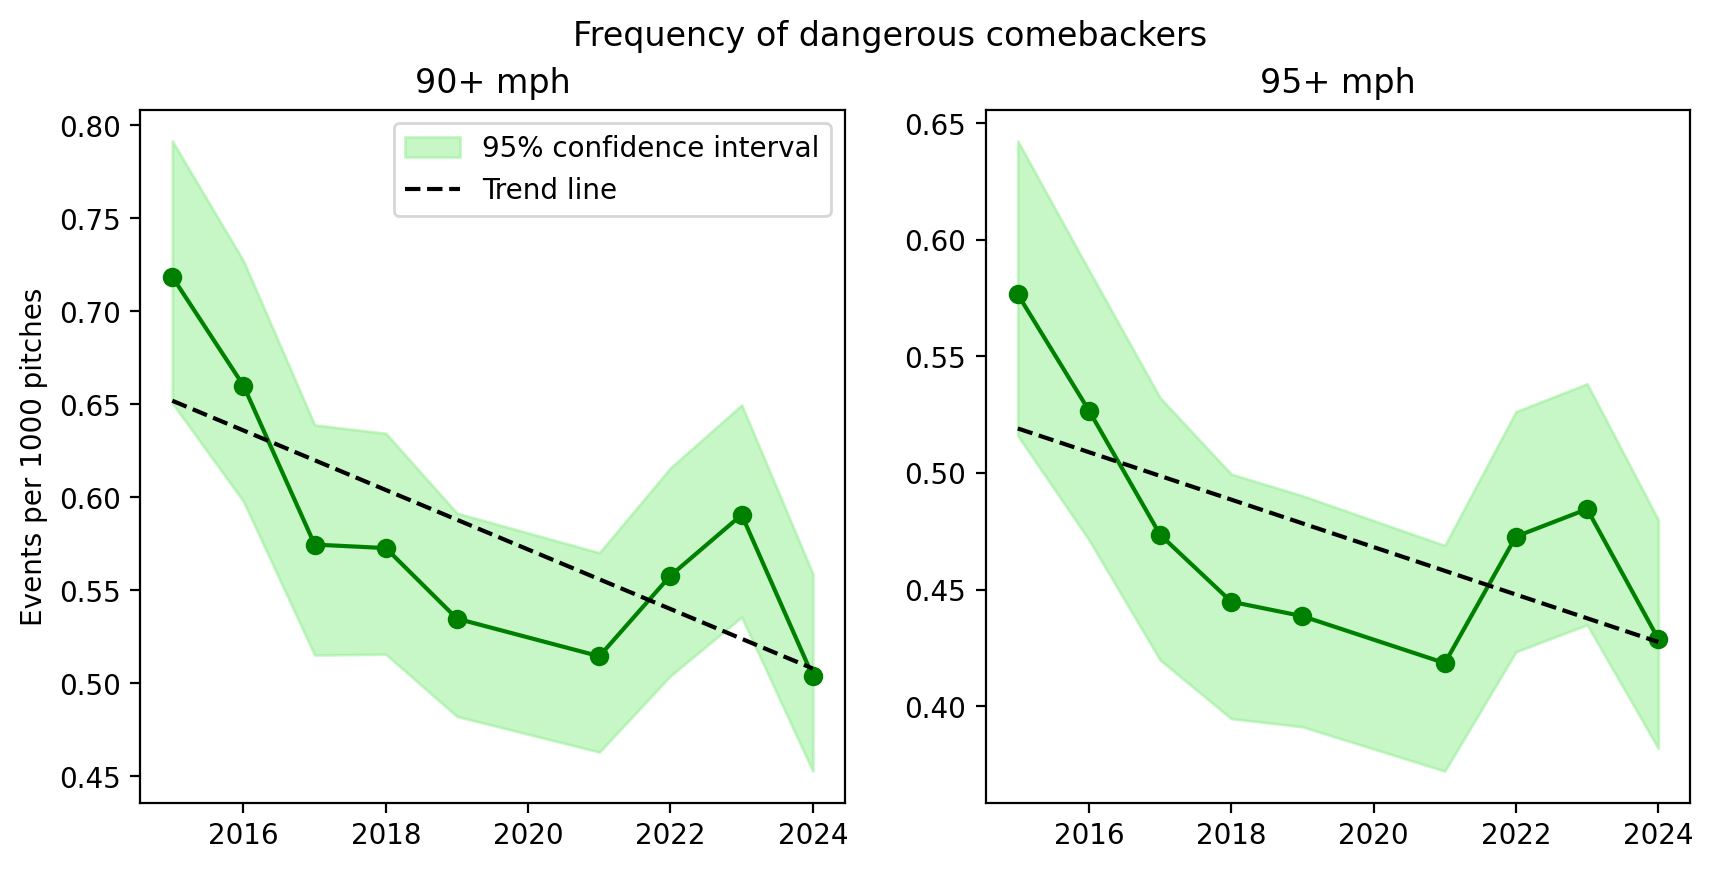

In [113]:

fig, axes = plt.subplots(1, 2, figsize=(10,4.5), dpi=200)
axes = np.array(axes).flatten()

for i, speed in enumerate([90, 95]):
    plt.sca(axes[i])

    values = danger_df[f"perpitch_danger_{speed}"].values.astype(float) * 1000

    plt.fill_between(
        EVAL_YEARS,
        danger_df[f"perpitch_ci_high_{speed}"].values * 1000,
        danger_df[f"perpitch_ci_low_{speed}"].values * 1000,
        color='lightgreen', 
        alpha=0.5,
        label="95% confidence interval",
    )
    plt.plot(EVAL_YEARS, values, c="green")
    plt.scatter(EVAL_YEARS, values, c="green")
    lr = scipy.stats.linregress(EVAL_YEARS, values)
    print(lr)
    print(values[-1] / values[0])
    plt.plot(
        EVAL_YEARS,
        (lr.slope * EVAL_YEARS + lr.intercept),
        c="black",
        linestyle="--",
        label="Trend line"
    )

    plt.title(f'{speed}+ mph')
    if i == 0:
        plt.ylabel("Events per 1000 pitches")
        plt.legend()

    # plt.ylim(0, 0.65)

plt.suptitle("Frequency of dangerous comebackers")

plt.savefig("figs/dangerous_bb_per_pitch.jpg", bbox_inches="tight")

LinregressResult(slope=-0.0772925524978282, intercept=159.4133924595248, rvalue=-0.7535486115563939, pvalue=0.019040745182444963, stderr=0.025486012697576988, intercept_stderr=51.46764440145474)
0.7349773091930997
LinregressResult(slope=-0.04674959673406717, intercept=97.12132396160297, rvalue=-0.6419384805876028, pvalue=0.06233017291057548, stderr=0.021105357095935945, intercept_stderr=42.62114387483697)
0.7795689279828111


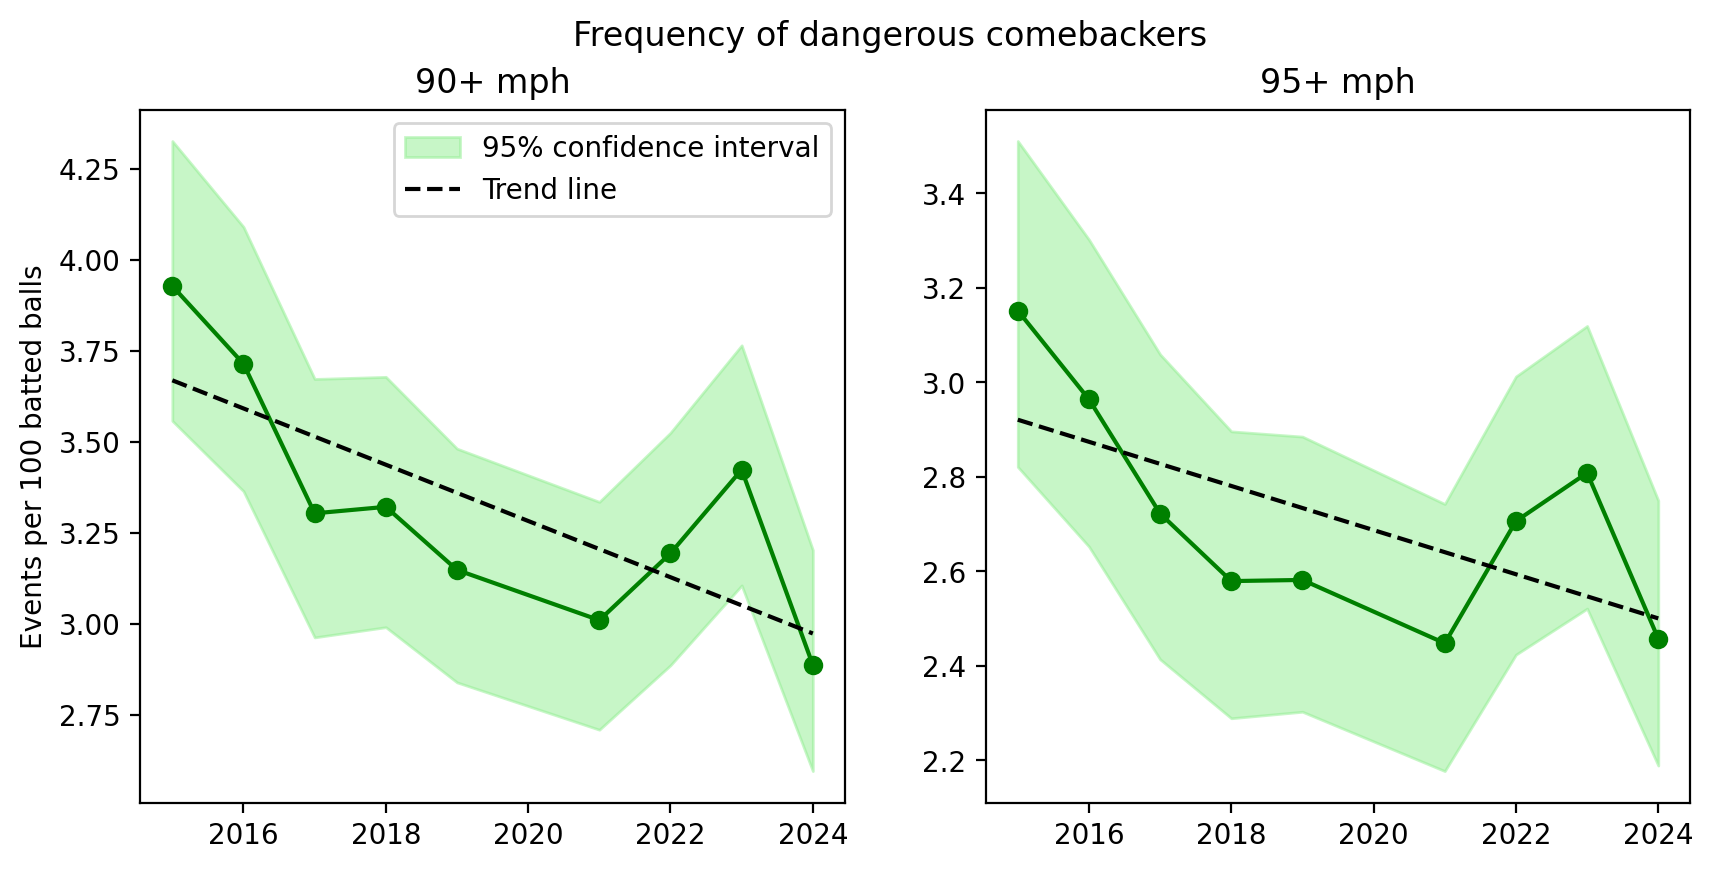

In [153]:

fig, axes = plt.subplots(1, 2, figsize=(10,4.5), dpi=200)
axes = np.array(axes).flatten()

for i, speed in enumerate([90, 95]):
    plt.sca(axes[i])

    values = danger_df[f"perbb_danger_{speed}"].values.astype(float) * 1000

    plt.fill_between(
        EVAL_YEARS,
        danger_df[f"perbb_ci_high_{speed}"].values * 1000,
        danger_df[f"perbb_ci_low_{speed}"].values * 1000,
        color='lightgreen', 
        alpha=0.5,
        label="95% confidence interval",
    )
    plt.plot(EVAL_YEARS, values, c="green")
    plt.scatter(EVAL_YEARS, values, c="green")
    lr = scipy.stats.linregress(EVAL_YEARS, values)
    print(lr)
    print(values[-1] / values[0])
    plt.plot(
        EVAL_YEARS,
        (lr.slope * EVAL_YEARS + lr.intercept),
        c="black",
        linestyle="--",
        label="Trend line"
    )

    plt.title(f'{speed}+ mph')
    if i == 0:
        plt.ylabel("Events per 100 batted balls")
        plt.legend()

    # plt.ylim(0, 0.65)

plt.suptitle("Frequency of dangerous comebackers")

plt.savefig("figs/dangerous_bb_per_bb.jpg", bbox_inches="tight")

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or R

LinregressResult(slope=0.5884339453989443, intercept=-1136.975499743505, rvalue=0.9254206547922461, pvalue=0.0003465647915353151, stderr=0.09107131467819009, intercept_stderr=183.91366647461876)
1.087741648074527
LinregressResult(slope=0.4605904419937636, intercept=-908.4890847942016, rvalue=0.9290468037190288, pvalue=0.0002921415355481042, stderr=0.06932432864077642, intercept_stderr=139.99678714718206)
1.1869186887532674
LinregressResult(slope=0.2658122480369487, intercept=-528.6491751496793, rvalue=0.911581069498718, pvalue=0.0006201675031187835, stderr=0.045310584011888394, intercept_stderr=91.50230964798286)
1.3303617120175306
LinregressResult(slope=0.050238461905681875, intercept=-100.11115854745883, rvalue=0.8078039558348129, pvalue=0.008444528813166994, stderr=0.013855724119475787, intercept_stderr=27.980896437897382)
1.4131029052691175


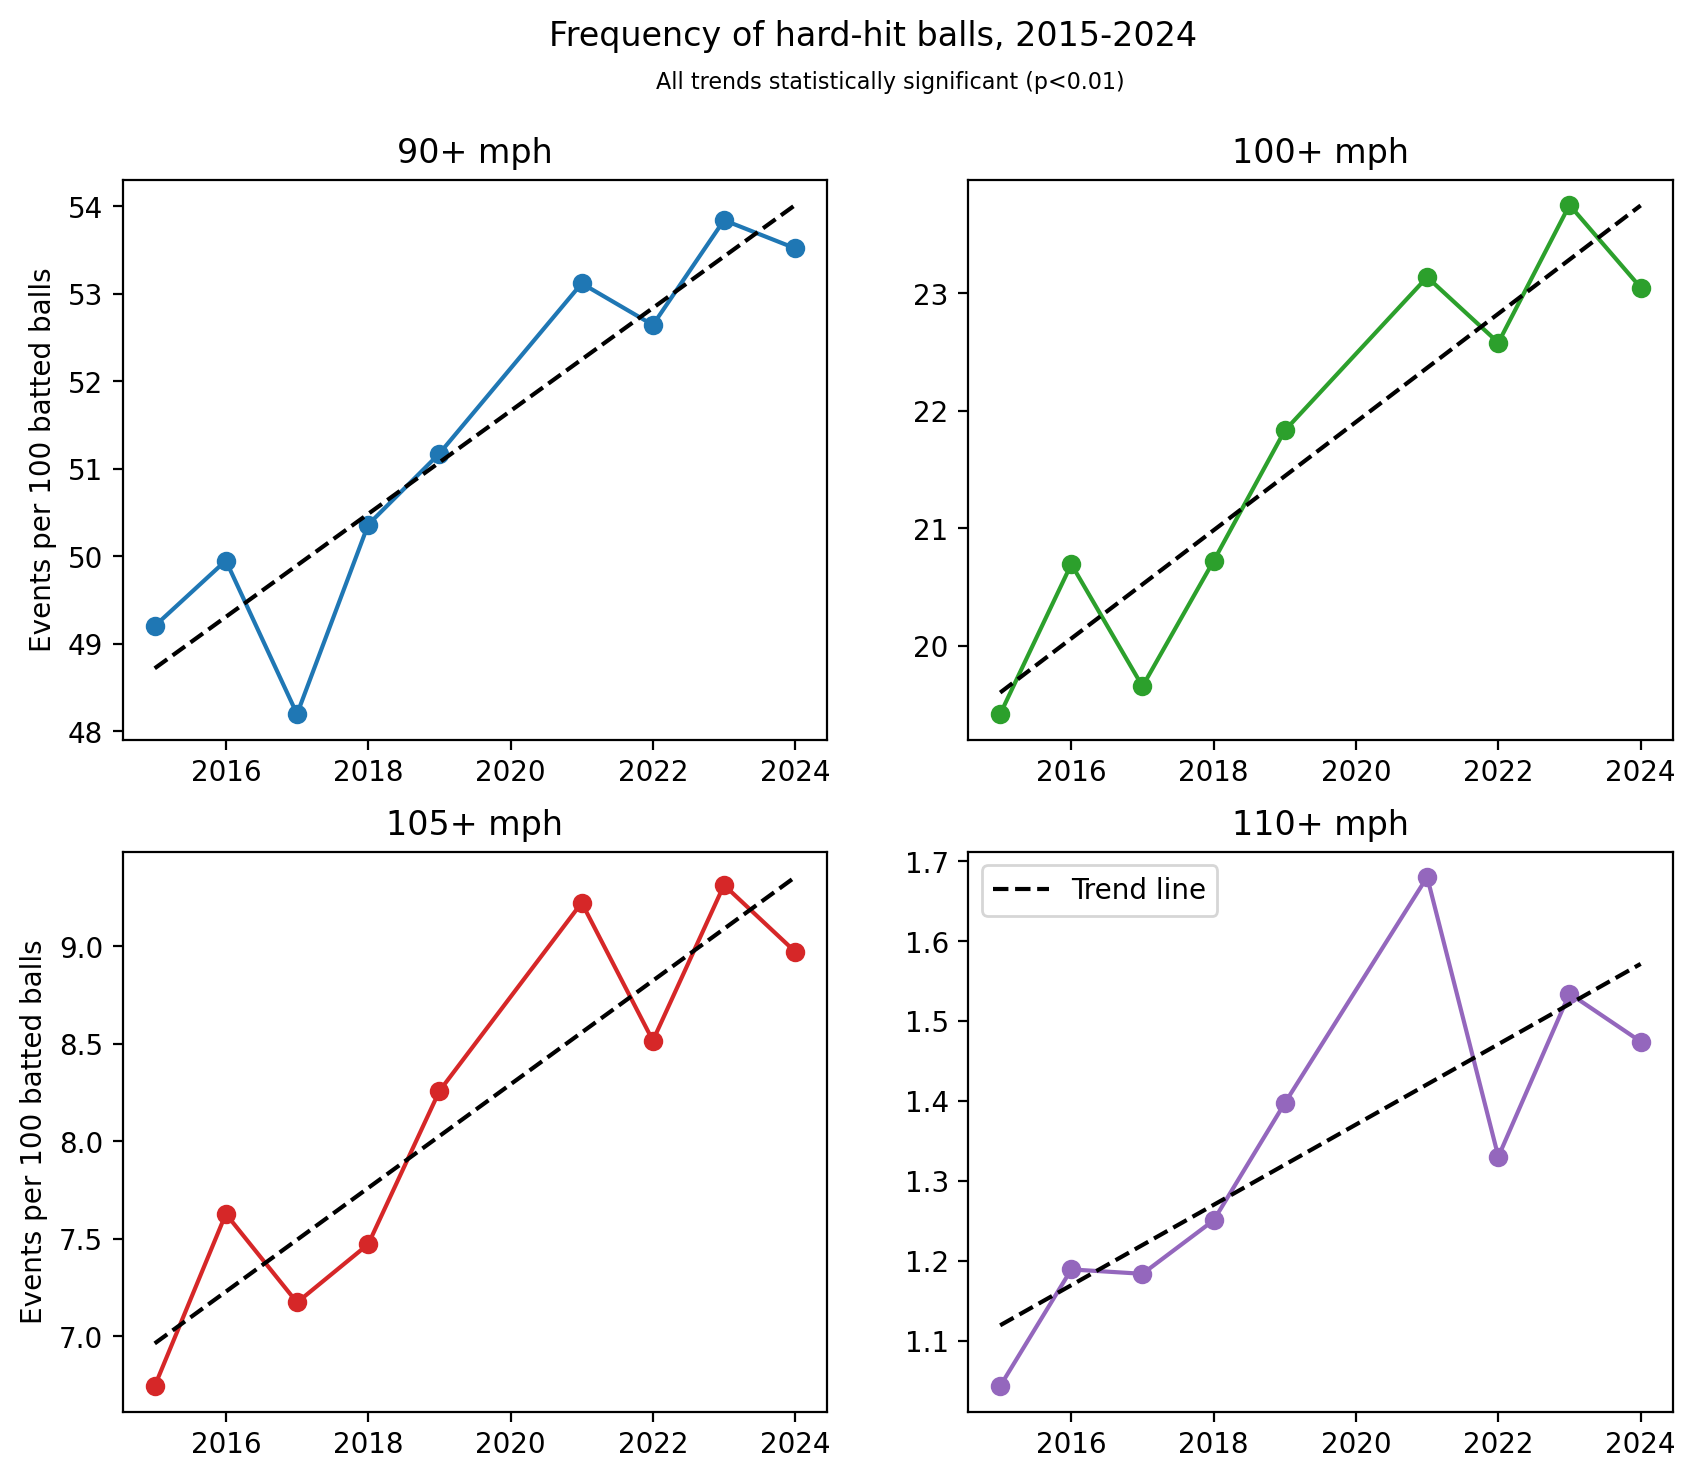

In [139]:
fig, axes = plt.subplots(2, 2, figsize=(10,8), dpi=200)
axes = np.array(axes).flatten()

palette = plt.get_cmap("tab10")([0, 2, 3, 4])
speeds = ["90+", "100+", "105+", "110+"]
for i, speed in enumerate(speeds):
    plt.sca(axes[i])
    data = (danger_df[speed] / danger_df.bb).values.astype(float) * 100
    plt.plot(EVAL_YEARS, data, c=palette[i])
    plt.scatter(EVAL_YEARS, data, c=palette[i])
    lr = scipy.stats.linregress(EVAL_YEARS, data)
    print(lr)
    print(data[-1] / data[0])
    plt.plot(
        EVAL_YEARS,
        lr.slope * EVAL_YEARS + lr.intercept,
        c="black",
        linestyle="--",
        label="Trend line",
    )
    plt.title(speed + " mph")
    if speed in speeds[::2]:
        plt.ylabel("Events per 100 batted balls")
    # plt.ylim(0, None)
plt.legend()
plt.suptitle("Frequency of hard-hit balls, 2015-2024")
plt.annotate("All trends statistically significant (p<0.01)", (0.445, 0.88), xycoords="figure fraction", fontsize=8, va="top", ha="center")

plt.savefig(
    "figs/hard_hit_rates.jpg",
    bbox_inches="tight",
)

LinregressResult(slope=0.2062391789565631, intercept=-410.1389347970115, rvalue=0.9862037102565774, pvalue=1.001994758736548e-06, stderr=0.013084241960402077, intercept_stderr=26.42292933270767)
LinregressResult(slope=0.2681361230457957, intercept=-528.4040588640903, rvalue=0.8806276696679125, pvalue=0.0017186610055050307, stderr=0.05452770578546209, intercept_stderr=110.11579585613724)

LinregressResult(slope=0.18827685817880807, intercept=-372.27251898487987, rvalue=0.9864233760308372, pvalue=9.474621006306121e-07, stderr=0.01184721773979198, intercept_stderr=23.92482484465646)
LinregressResult(slope=0.16341058920387475, intercept=-317.61194108211276, rvalue=0.7317315319580463, pvalue=0.025031153230709438, stderr=0.057531341745148075, intercept_stderr=116.18147860215728)

LinregressResult(slope=0.1470721062851861, intercept=-286.52438234497504, rvalue=0.9508591192029447, pvalue=8.253796932681257e-05, stderr=0.01810087371814926, intercept_stderr=36.55374981312452)
LinregressResult(slo

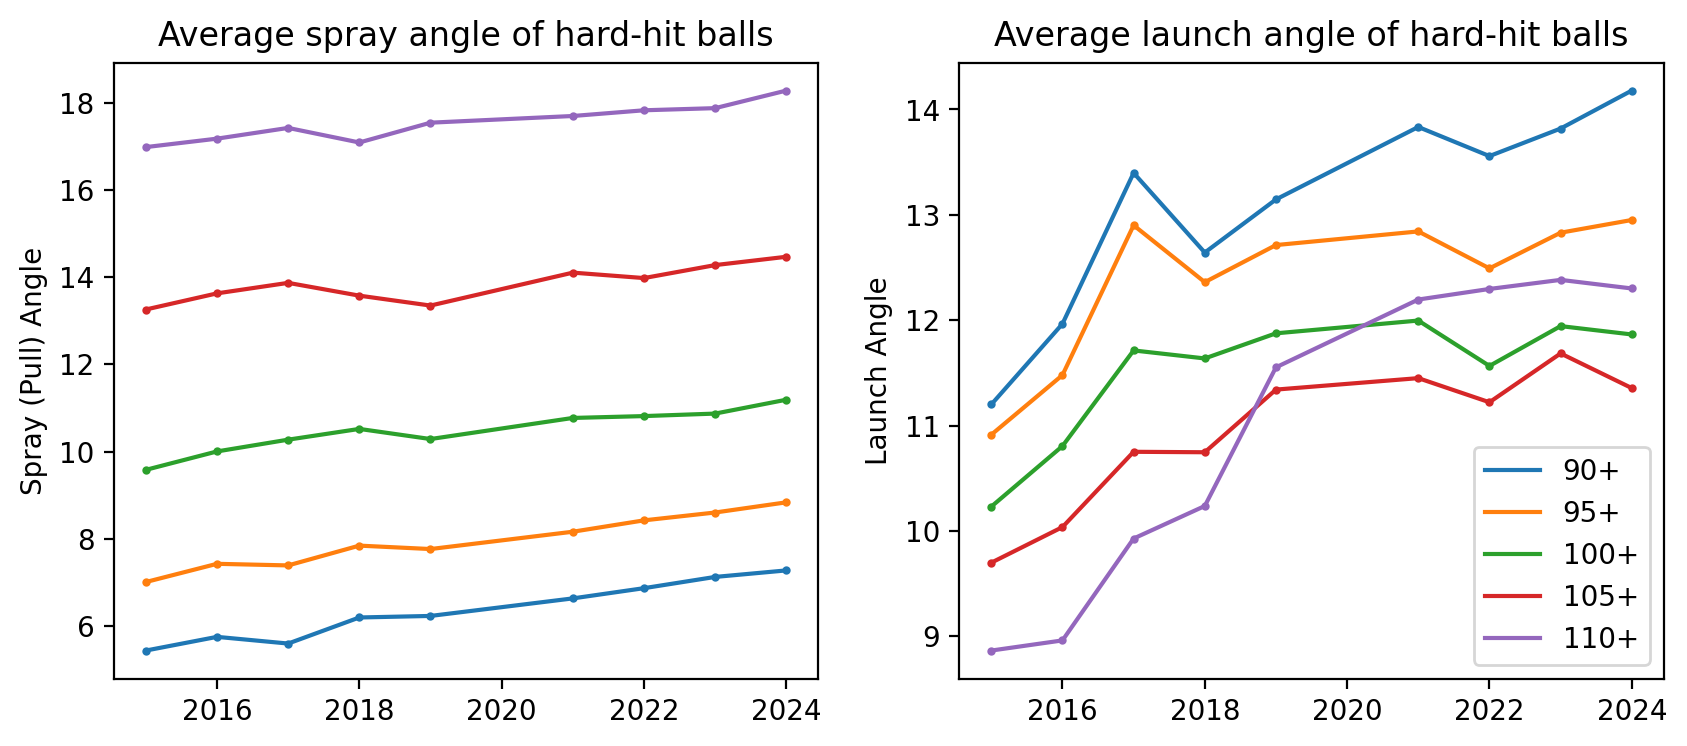

In [140]:
fig, axes = plt.subplots(1, 2, figsize=(10,4), dpi=200)

for speed in [90, 95, 100, 105, 110]:
    plt.sca(axes[0])
    data = -BB_DF[BB_DF.launch_speed >= speed].groupby("game_year").spray_angle_relative.mean()
    data = data.loc[EVAL_YEARS].copy()
    data = data.values.astype(float)
    print(scipy.stats.linregress(EVAL_YEARS, data))
    plt.plot(EVAL_YEARS, data, label=f"{speed}+")
    plt.scatter(EVAL_YEARS, data, s=4)
    # plt.legend(loc="lower right")
    # space = " "*20
    plt.ylabel("Spray (Pull) Angle")
    plt.xlabel("")
    plt.title("Average spray angle of hard-hit balls")

    plt.sca(axes[1])
    data = BB_DF[BB_DF.launch_speed >= speed].groupby("game_year").launch_angle.mean()
    data = data.loc[EVAL_YEARS].copy()
    data = data.values.astype(float)
    print(scipy.stats.linregress(EVAL_YEARS, data))
    plt.plot(EVAL_YEARS, data, label=f"{speed}+")
    plt.scatter(EVAL_YEARS, data, s=4)
    plt.legend()
    plt.ylabel("Launch Angle")
    plt.xlabel("")
    plt.title("Average launch angle of hard-hit balls")

    print()

plt.savefig("figs/launch_and_spray.jpg", bbox_inches="tight")

<AxesSubplot: >

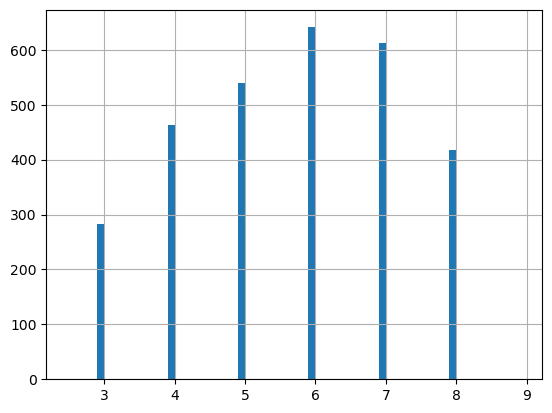

In [40]:
BB_DF[BB_DF.is_dangerous_95].launch_angle.hist(bins=np.arange(2.5, 9, 0.1))

<AxesSubplot: >

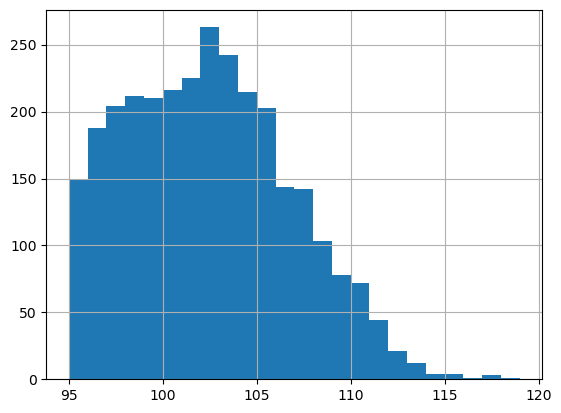

In [94]:
BB_DF[BB_DF.is_dangerous_95].launch_speed.hist(bins=np.arange(95, 120))

<AxesSubplot: >

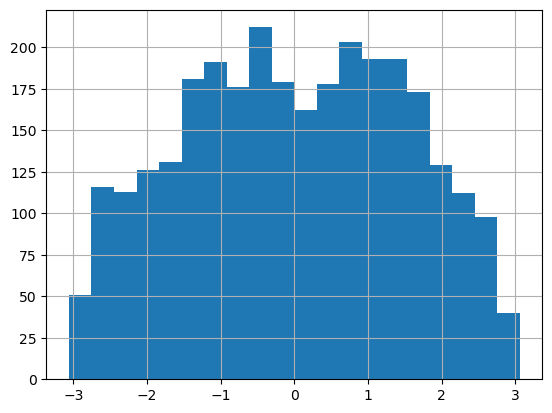

In [95]:
BB_DF[BB_DF.is_dangerous_95].spray_angle.hist(bins=20)